In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
import os
print(os.getcwd())  # This prints your current folder path
print(os.listdir()) # This lists all files in that folder


C:\Users\ELCOT
['.accessibility.properties', '.copilot', '.dbus-keyrings', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.ms-ad', '.python_history', '.vscode', '.vscode-shared', '.wslconfig', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'customer_Intelligence.ipynb', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TM.blf', 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TM.blf.cnpf', 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TMContainer00000000000000000001.regtrans-ms.cnpf', 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TMContainer00000000000000000002.regtrans-ms', 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TMContainer00000000000000000002.regtrans-ms.cnpf', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 

In [4]:
import pandas as pd

# Update the paths to point directly to your Downloads folder
project_transactions = pd.read_csv(r"C:\Users\ELCOT\Downloads\project_transactions.csv")
product = pd.read_csv(r"C:\Users\ELCOT\Downloads\product.csv")
hh_demographic = pd.read_csv(r"C:\Users\ELCOT\Downloads\hh_demographic.csv")

print("Files loaded successfully!")


Files loaded successfully!


In [90]:
project_transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.19,31742,0.00,1,0.0,0.0
1,1364,26984896261,1,897044,1,2.99,31742,-0.40,1,0.0,0.0
2,1364,26984896261,1,920955,1,3.09,31742,0.00,1,0.0,0.0
3,1364,26984896261,1,937406,1,2.50,31742,-0.99,1,0.0,0.0
4,1364,26984896261,1,981760,1,0.60,31742,-0.79,1,0.0,0.0


In [5]:
#TOTAL SALES
customer_sales = (project_transactions.groupby("household_key")["SALES_VALUE"].sum().reset_index())
customer_sales

,household_key,SALES_VALUE
0,1,4330.16
1,2,1954.34
2,3,2653.21
3,4,1200.11
4,5,779.06
...,...,...
2094,2095,3790.49
2095,2096,1301.65
2096,2097,8823.83
2097,2098,682.46


In [6]:
customer_sales.sort_values("SALES_VALUE", ascending=False).head(10)

,household_key,SALES_VALUE
1022,1023,38319.79
1608,1609,27859.68
1452,1453,21661.29
1429,1430,20352.99
717,718,19299.86
706,707,19194.42
1652,1653,19153.75
1110,1111,18894.72
981,982,18790.34
399,400,18494.14


In [7]:
#coustomer frequency
customer_freqency =(project_transactions.groupby("household_key")["BASKET_ID"].nunique().reset_index(name="frequency"))
customer_freqency

,household_key,frequency
0,1,86
1,2,45
2,3,47
3,4,30
4,5,40
...,...,...
2094,2095,164
2095,2096,26
2096,2097,202
2097,2098,13


In [8]:
#avgerage sales
basket_sales=(project_transactions.groupby(["household_key","BASKET_ID"])["SALES_VALUE"].sum().reset_index())
basket_sales

,household_key,BASKET_ID,SALES_VALUE
0,1,27601281299,78.66
1,1,27774192959,41.10
2,1,28024266849,26.90
3,1,28106322445,63.43
4,1,28235481967,53.45
...,...,...,...
232934,2099,41679080790,11.04
232935,2099,41730701574,16.78
232936,2099,42049670968,12.91
232937,2099,42076788892,2.78


In [9]:
customer_basket=(basket_sales.groupby("household_key")["SALES_VALUE"].mean().reset_index(name="avg_basket_sales"))
customer_basket

,household_key,avg_basket_sales
0,1,50.350698
1,2,43.429778
2,3,56.451277
3,4,40.003667
4,5,19.476500
...,...,...
2094,2095,23.112744
2095,2096,50.063462
2096,2097,43.682327
2097,2098,52.496923


In [10]:
#total quantity purchased
customer_quantity=(project_transactions.groupby("household_key")["QUANTITY"].sum().reset_index(name="total_units"))
customer_quantity

,household_key,total_units
0,1,1997
1,2,834
2,3,8540
3,4,382
4,5,245
...,...,...
2094,2095,80276
2095,2096,618
2096,2097,692236
2097,2098,279


In [11]:
#recently shop

last_purchase=(project_transactions.groupby("household_key")["DAY"].max().reset_index(name="last_purchase_day"))
last_purchase

,household_key,last_purchase_day
0,1,706
1,2,668
2,3,703
3,4,627
4,5,703
...,...,...
2094,2095,711
2095,2096,591
2096,2097,645
2097,2098,632


In [12]:
reference_day=project_transactions["DAY"].max()
reference_day

np.int64(711)

In [13]:
last_purchase["recency"]=(reference_day - last_purchase["last_purchase_day"])

In [14]:
last_purchase.head()

,household_key,last_purchase_day,recency
0,1,706,5
1,2,668,43
2,3,703,8
3,4,627,84
4,5,703,8


In [15]:
customer_analysis=(customer_sales.merge(customer_freqency,on="household_key").merge(customer_basket,on="household_key").merge(
    customer_quantity,on="household_key").merge(last_purchase,on="household_key"))

In [16]:
customer_analysis

,household_key,SALES_VALUE,frequency,avg_basket_sales,total_units,last_purchase_day,recency
0,1,4330.16,86,50.350698,1997,706,5
1,2,1954.34,45,43.429778,834,668,43
2,3,2653.21,47,56.451277,8540,703,8
3,4,1200.11,30,40.003667,382,627,84
4,5,779.06,40,19.476500,245,703,8
...,...,...,...,...,...,...,...
2094,2095,3790.49,164,23.112744,80276,711,0
2095,2096,1301.65,26,50.063462,618,591,120
2096,2097,8823.83,202,43.682327,692236,645,66
2097,2098,682.46,13,52.496923,279,632,79


In [17]:
#highly purchased sales values
customer_analysis.sort_values("SALES_VALUE",ascending=False).head(10)

,household_key,SALES_VALUE,frequency,avg_basket_sales,total_units,last_purchase_day,recency
1022,1023,38319.79,603,63.548574,4479917,710,1
1608,1609,27859.68,412,67.620583,2146715,711,0
1452,1453,21661.29,761,28.464244,95743,710,1
1429,1430,20352.99,344,59.165669,1741892,711,0
717,718,19299.86,599,32.220134,869732,707,4
706,707,19194.42,498,38.543012,1640193,711,0
1652,1653,19153.75,541,35.404344,1065654,710,1
1110,1111,18894.72,321,58.862056,11216,707,4
981,982,18790.34,412,45.607621,1329976,710,1
399,400,18494.14,310,59.658516,862525,711,0


In [18]:
#customer who shop most frequently
customer_analysis.sort_values("frequency",ascending=False).head(10)

,household_key,SALES_VALUE,frequency,avg_basket_sales,total_units,last_purchase_day,recency
1509,1510,11211.37,1300,8.624131,595975,711,0
899,900,16450.53,1223,13.450965,1264243,711,0
1794,1795,9751.73,1138,8.569183,128554,710,1
761,762,8982.79,886,10.138589,349858,711,0
1900,1901,11462.24,852,13.453333,60290,711,0
1466,1467,2957.82,835,3.542299,161157,711,0
1227,1228,14503.89,797,18.198105,1085371,711,0
1452,1453,21661.29,761,28.464244,95743,710,1
1706,1707,6580.49,749,8.785701,3255,709,2
1478,1479,9129.23,716,12.750321,208370,709,2


In [39]:
low_sales=customer_analysis["SALES_VALUE"].quantile(0.25)
low_sales

np.float64(971.0350000000001)

In [40]:
high_sales= customer_analysis["SALES_VALUE"].quantile(0.75)
high_sales

np.float64(4295.395)

In [41]:
customer_analysis["value"]=np.select([customer_analysis["SALES_VALUE"] <= low,customer_analysis["SALES_VALUE"] >= high],
                                     ["low value","high value"],default="medium value")

In [50]:
value_count = customer_analysis["value"].value_counts().reset_index()
value_count

,value,count
0,medium value,1049
1,high value,525
2,low value,525


In [52]:
value_count.columns=["values","customer_count"]
value_count

,values,customer_count
0,medium value,1049
1,high value,525
2,low value,525


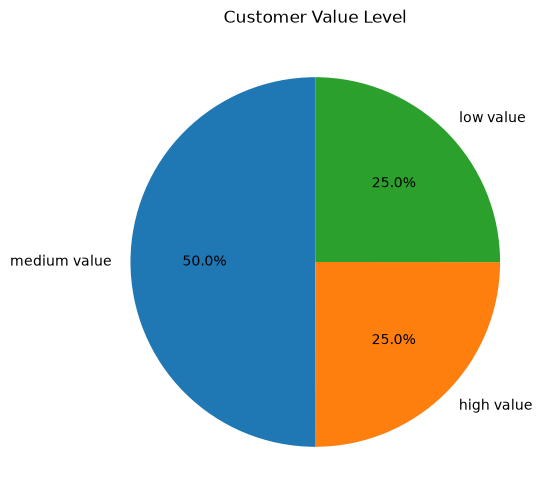

In [55]:
plt.figure(figsize=(6, 6))
plt.pie(
    value_count["customer_count"],
    labels=value_count["values"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Value Level")
plt.show()

In [42]:
customer_analysis

,household_key,SALES_VALUE,frequency,avg_basket_sales,total_units,last_purchase_day,recency,value,loyal,basket,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,1,4330.16,86,50.350698,1997,706,5,high value,Not Loyal,big basket,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown
1,2,1954.34,45,43.429778,834,668,43,medium value,Not Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2653.21,47,56.451277,8540,703,8,medium value,Not Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1200.11,30,40.003667,382,627,84,medium value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,779.06,40,19.476500,245,703,8,low value,Not Loyal,small basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,2095,3790.49,164,23.112744,80276,711,0,medium value,High Loyal,small basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2095,2096,1301.65,26,50.063462,618,591,120,medium value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2096,2097,8823.83,202,43.682327,692236,645,66,high value,High Loyal,big basket,35-44,A,15-24K,Homeowner,2 Adults Kids,5+,3+
2097,2098,682.46,13,52.496923,279,632,79,low value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
low_frq = customer_analysis["frequency"].quantile(0.25)
low_frq

np.float64(38.5)

In [44]:
high_frq= customer_analysis["frequency"].quantile(0.75)
high_frq

np.float64(144.0)

In [45]:
customer_analysis["loyal"]=np.select([customer_analysis["frequency"] >= high_frq,
        customer_analysis["frequency"] < low_frq],["High Loyal","Loyal"],default="Not Loyal")

In [58]:
loyal_count=customer_analysis["loyal"].value_counts().reset_index()
loyal_count

,loyal,count
0,Not Loyal,1048
1,High Loyal,526
2,Loyal,525


In [59]:
loyal_count.columns = ["loyalty_level", "customer_count"]
loyal_count

,loyalty_level,customer_count
0,Not Loyal,1048
1,High Loyal,526
2,Loyal,525


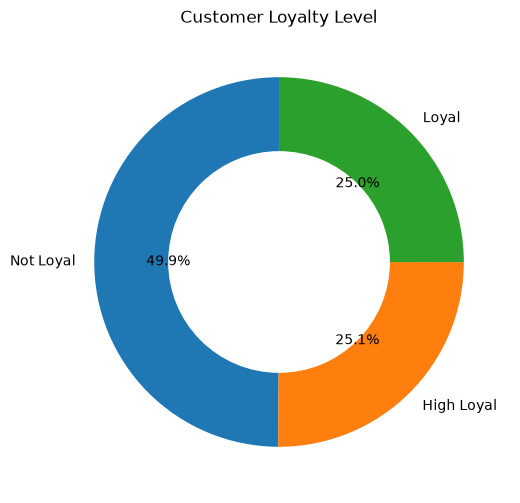

In [60]:
plt.figure(figsize=(6, 6))

plt.pie(
    loyal_count["customer_count"],
    labels=loyal_count["loyalty_level"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Customer Loyalty Level")
plt.show()

In [47]:
median_basket=customer_analysis["avg_basket_sales"].median() 
median_basket

np.float64(27.091315789473686)

In [48]:
customer_analysis["basket"]=np.where(customer_analysis["avg_basket_sales"] >= median_basket,"big basket","small basket")
customer_analysis

,household_key,SALES_VALUE,frequency,avg_basket_sales,total_units,last_purchase_day,recency,value,loyal,basket,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,1,4330.16,86,50.350698,1997,706,5,high value,Not Loyal,big basket,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown
1,2,1954.34,45,43.429778,834,668,43,medium value,Not Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2653.21,47,56.451277,8540,703,8,medium value,Not Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1200.11,30,40.003667,382,627,84,medium value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,779.06,40,19.476500,245,703,8,low value,Not Loyal,small basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,2095,3790.49,164,23.112744,80276,711,0,medium value,High Loyal,small basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2095,2096,1301.65,26,50.063462,618,591,120,medium value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2096,2097,8823.83,202,43.682327,692236,645,66,high value,High Loyal,big basket,35-44,A,15-24K,Homeowner,2 Adults Kids,5+,3+
2097,2098,682.46,13,52.496923,279,632,79,low value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
basket_count = customer_analysis["basket"].value_counts().reset_index()
basket_count.columns = ["basket_level", "customer_count"]
basket_count

,basket_level,customer_count
0,big basket,1050
1,small basket,1049


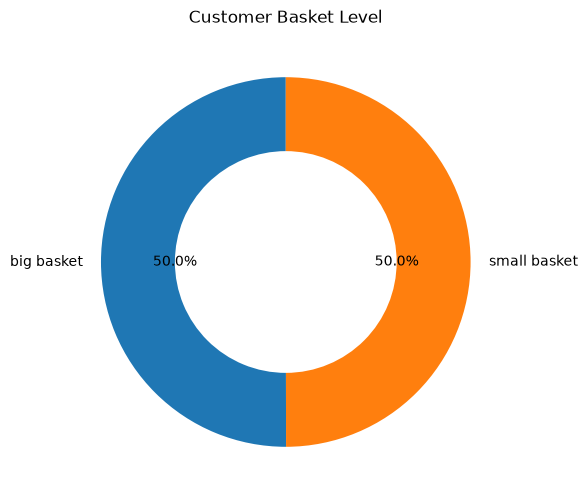

In [62]:
plt.figure(figsize=(6, 6))

plt.pie(
    basket_count["customer_count"],
    labels=basket_count["basket_level"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Customer Basket Level")
plt.show()

In [29]:
hh_demographic

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16
...,...,...,...,...,...,...,...,...
796,35-44,U,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,2494
797,45-54,A,75-99K,Homeowner,Unknown,3,1,2496
798,45-54,U,35-49K,Unknown,Single Male,1,None/Unknown,2497
799,25-34,U,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,2498


In [30]:
customer_analysis = customer_analysis.merge(hh_demographic,on="household_key",how="left")
customer_analysis

,household_key,SALES_VALUE,frequency,avg_basket_sales,total_units,last_purchase_day,recency,value,loyal,basket,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,1,4330.16,86,50.350698,1997,706,5,high value,Not Loyal,big basket,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown
1,2,1954.34,45,43.429778,834,668,43,medium value,Not Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2653.21,47,56.451277,8540,703,8,medium value,Not Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1200.11,30,40.003667,382,627,84,medium value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,779.06,40,19.476500,245,703,8,low value,Not Loyal,small basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,2095,3790.49,164,23.112744,80276,711,0,medium value,High Loyal,small basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2095,2096,1301.65,26,50.063462,618,591,120,medium value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2096,2097,8823.83,202,43.682327,692236,645,66,high value,High Loyal,big basket,35-44,A,15-24K,Homeowner,2 Adults Kids,5+,3+
2097,2098,682.46,13,52.496923,279,632,79,low value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Sales by Age Group'}, xlabel='Age group', ylabel='Total sales'>

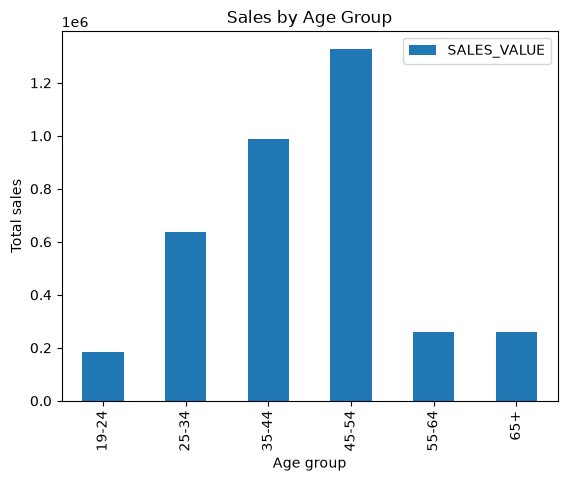

In [69]:
age_sales = (customer_analysis.groupby("AGE_DESC")["SALES_VALUE"].sum().reset_index())
age_sales.plot.bar(x="AGE_DESC",y="SALES_VALUE",xlabel="Age group",ylabel="Total sales",title="Sales by Age Group")

In [32]:
income_sales=(customer_analysis.groupby("INCOME_DESC")["SALES_VALUE"].sum().reset_index())
income_sales

,INCOME_DESC,SALES_VALUE
0,100-124K,176701.11
1,125-149K,243900.83
2,15-24K,274757.94
3,150-174K,199350.78
4,175-199K,50970.79
5,200-249K,24232.17
6,25-34K,297183.42
7,250K+,51715.16
8,35-49K,706011.17
9,50-74K,878344.14


<Axes: title={'center': 'Sales by Income Group'}, xlabel='Income Group', ylabel='Total Sales'>

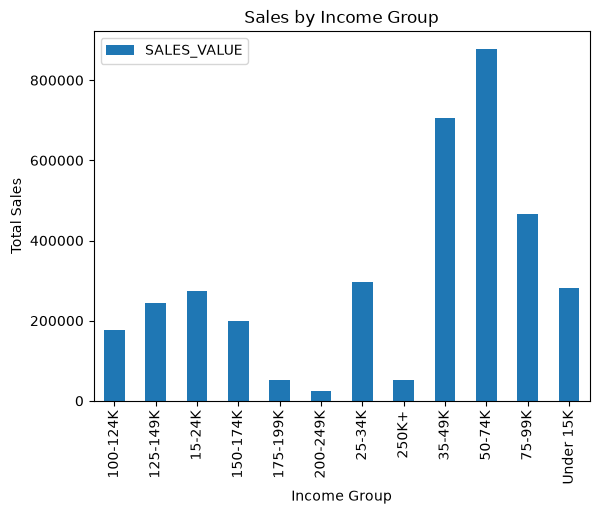

In [73]:
income_sales.plot.bar(x="INCOME_DESC",y="SALES_VALUE",xlabel="Income Group",ylabel="Total Sales",title="Sales by Income Group")

In [33]:
household_size=(customer_analysis.groupby("HOUSEHOLD_SIZE_DESC")["SALES_VALUE"].sum().reset_index())
household_size

,HOUSEHOLD_SIZE_DESC,SALES_VALUE
0,1,1019052.04
1,2,1442107.38
2,3,545989.77
3,4,303417.96
4,5+,342323.21


<Axes: title={'center': 'Sales by Household Size'}, xlabel='Household Size', ylabel='Total Sales'>

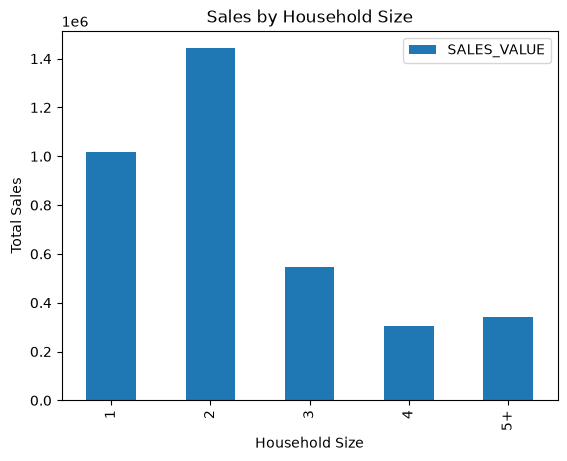

In [74]:
household_size.plot.bar(x="HOUSEHOLD_SIZE_DESC",y="SALES_VALUE",xlabel="Household Size",ylabel="Total Sales",title="Sales by Household Size")

In [34]:
kids_sales=(customer_analysis.groupby("KID_CATEGORY_DESC")["SALES_VALUE"].sum().reset_index())
kids_sales

,KID_CATEGORY_DESC,SALES_VALUE
0,1,569121.37
1,2,337613.75
2,3+,365363.56
3,None/Unknown,2380791.68


In [84]:
kids_count = customer_analysis["KID_CATEGORY_DESC"].value_counts()
label_map = {
    "1": "1 Kid",
    "2": "2 Kids",
    "3+": "3+ Kids",
    "None/Unknown": "Unknown"
}

kids_labels = kids_count.index.map(label_map)

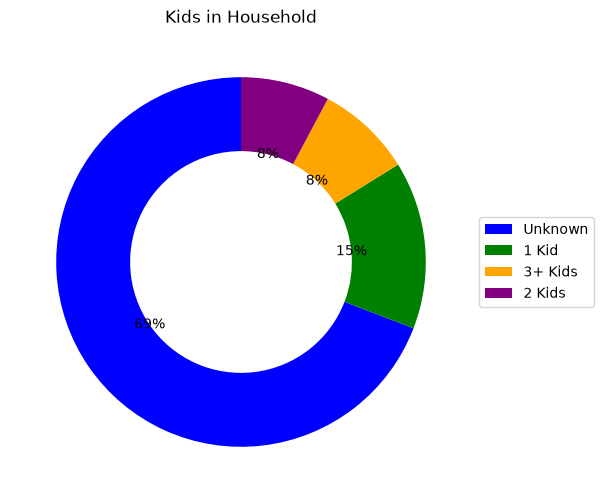

In [87]:
plt.figure(figsize=(6, 6))

plt.pie(
    kids_count,
    labels=None,
    autopct="%1.0f%%",
    startangle=90,
    colors=["blue","green","orange","purple"],
    wedgeprops={"width": 0.4}
)
plt.legend(kids_labels,loc="center left",bbox_to_anchor=(1,0.5))

plt.title("Kids in Household")
plt.show()

In [35]:
homeowner_sales=(customer_analysis.groupby("HOMEOWNER_DESC")["SALES_VALUE"].sum().reset_index())
homeowner_sales

,HOMEOWNER_DESC,SALES_VALUE
0,Homeowner,2387302.08
1,Probable Owner,54510.17
2,Probable Renter,39011.04
3,Renter,204455.72
4,Unknown,967611.35


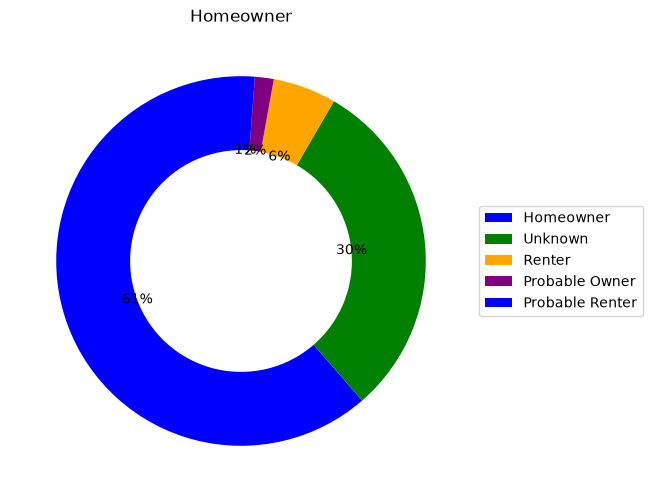

In [89]:
homeowner_count = customer_analysis["HOMEOWNER_DESC"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    homeowner_count,
    labels=None,
    autopct="%1.0f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width": 0.4}
)

plt.legend(
    homeowner_count.index,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Homeowner")
plt.show()

In [36]:
household_comp_basket = (customer_analysis.groupby("HH_COMP_DESC")["avg_basket_sales"].mean().reset_index())
household_comp_basket

,HH_COMP_DESC,avg_basket_sales
0,1 Adult Kids,40.851950
1,2 Adults Kids,40.641700
2,2 Adults No Kids,36.813807
3,Single Female,31.819828
4,Single Male,31.394254
5,Unknown,30.669222


In [37]:
customer_analysis.head()

,household_key,SALES_VALUE,frequency,avg_basket_sales,total_units,last_purchase_day,recency,value,loyal,basket,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC
0,1,4330.16,86,50.350698,1997,706,5,high value,Not Loyal,big basket,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown
1,2,1954.34,45,43.429778,834,668,43,medium value,Not Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2653.21,47,56.451277,8540,703,8,medium value,Not Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1200.11,30,40.003667,382,627,84,medium value,Loyal,big basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,779.06,40,19.476500,245,703,8,low value,Not Loyal,small basket,NaN,NaN,NaN,NaN,NaN,NaN,NaN
